In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("data.csv")
data.head()

,feature_name,lines_changed,files_changed,complexity_score,developer_experience,past_bug_count,commit_frequency,failed
0,Login API,120,4,15,2,3,8,1
1,Search Feature,45,2,6,4,0,3,0
2,Payment Module,200,6,18,1,4,10,1
3,Profile Update,30,1,4,3,0,2,0
4,Notification System,150,5,14,2,2,6,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   feature_name          16 non-null     object
 1   lines_changed         16 non-null     int64 
 2   files_changed         16 non-null     int64 
 3   complexity_score      16 non-null     int64 
 4   developer_experience  16 non-null     int64 
 5   past_bug_count        16 non-null     int64 
 6   commit_frequency      16 non-null     int64 
 7   failed                16 non-null     int64 
dtypes: int64(7), object(1)
memory usage: 1.1+ KB


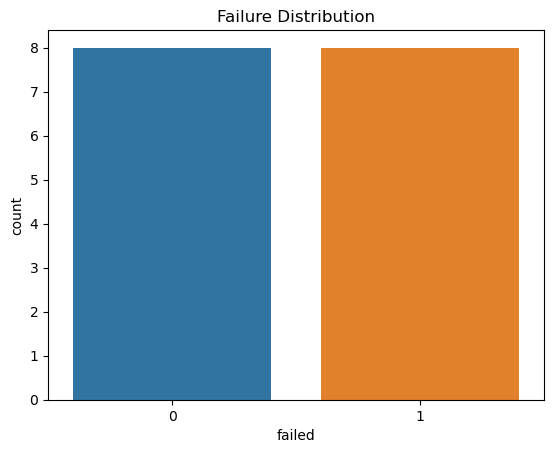

In [7]:
sns.countplot(x='failed', data=data)
plt.title("Failure Distribution")
plt.show()

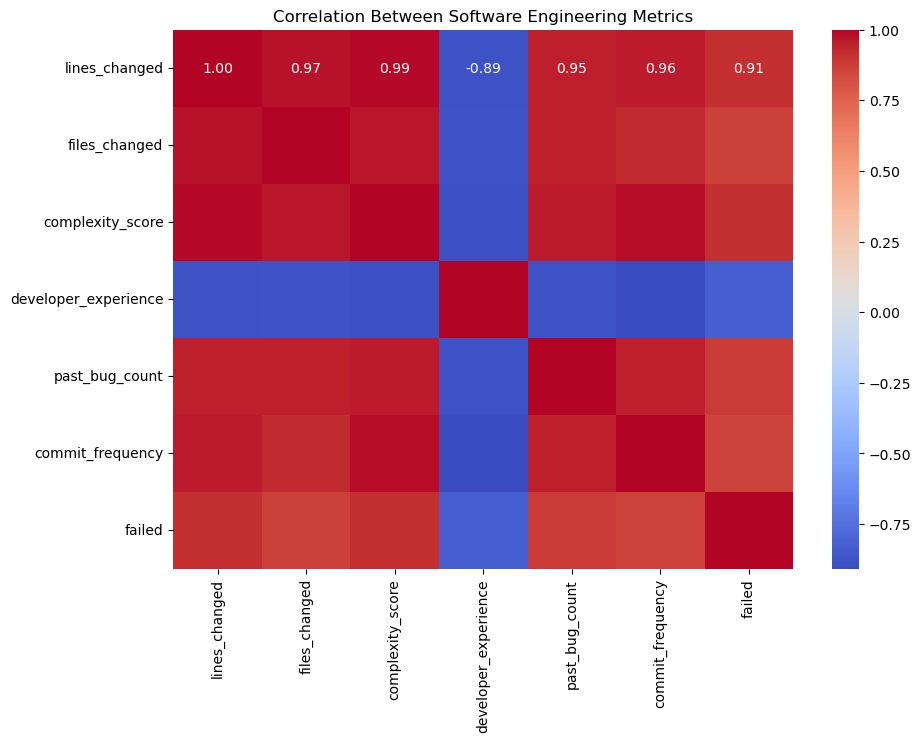

In [13]:
plt.figure(figsize=(10,7))

numeric_data = data.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Software Engineering Metrics")

plt.show()

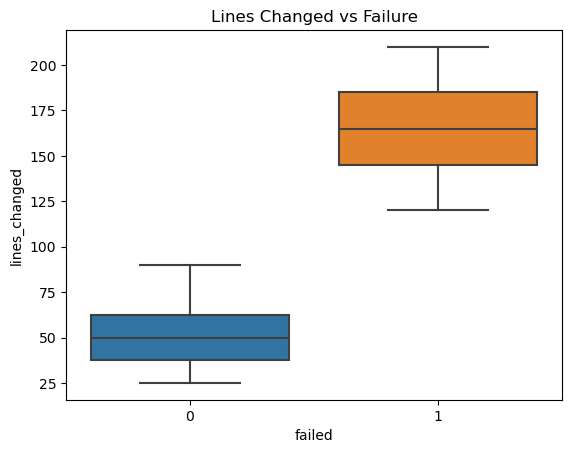

In [15]:
sns.boxplot(x="failed", y="lines_changed", data=data)
plt.title("Lines Changed vs Failure")
plt.show()

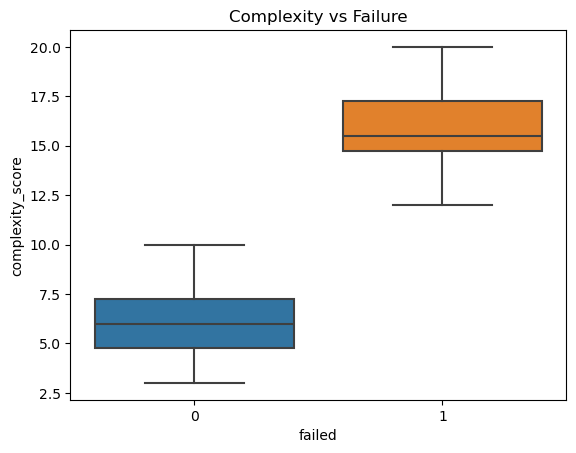

In [17]:
sns.boxplot(x="failed", y="complexity_score", data=data)
plt.title("Complexity vs Failure")
plt.show()

In [19]:
import pickle

model = pickle.load(open("model.pkl","rb"))

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


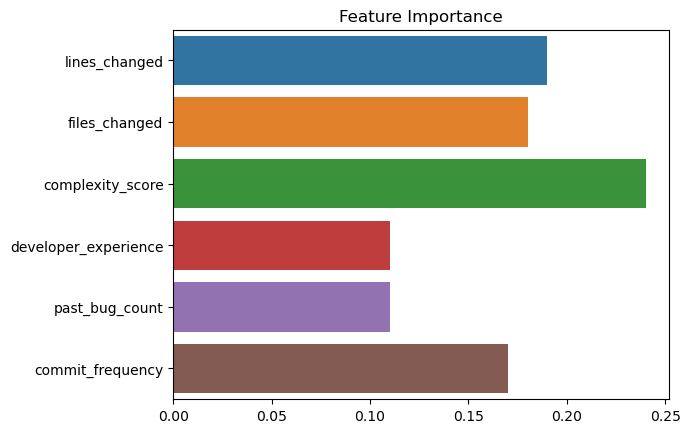

In [21]:
importance = model.feature_importances_

features = [
"lines_changed",
"files_changed",
"complexity_score",
"developer_experience",
"past_bug_count",
"commit_frequency"
]

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")
plt.show()